In [107]:
import warnings
warnings.filterwarnings('ignore')

In [108]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

from dash import Dash, html, dcc, dash_table, Input, Output, callback
import dash_bootstrap_components as dbc

In [109]:
pd.set_option('display.max_columns', 100)

In [110]:
dem_uncont = 34
rep_uncont = 31

In [111]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont)
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims

,seats,winner
0,53,Democrats
1,54,Democrats
2,46,Republicans
3,53,Democrats
4,48,Republicans
...,...,...
7995,51,Democrats
7996,52,Democrats
7997,53,Democrats
7998,50,Republicans


In [112]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 51 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 51 else (100-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,38,1,0.0125,Republicans
1,39,1,0.0125,Republicans
2,40,3,0.0375,Republicans
3,41,2,0.0250,Republicans
4,42,14,0.1750,Republicans


In [113]:
np.unique(seat_sims['seats']).shape[0]

26

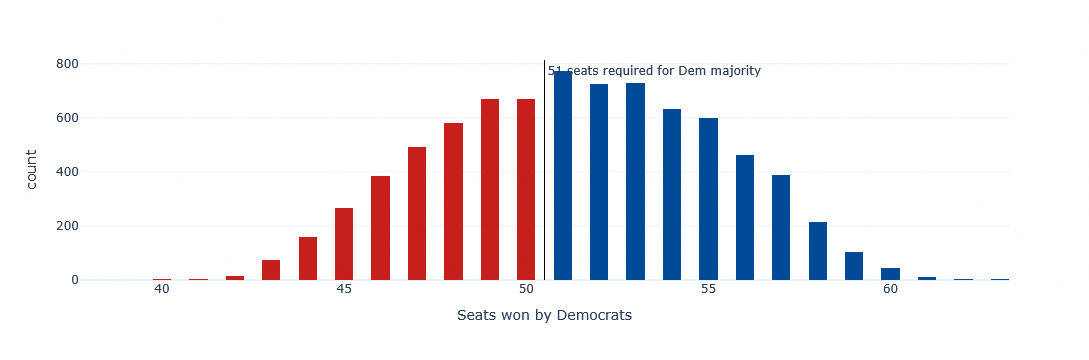

In [114]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'}, template='plotly_white')
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=50.5, line_width=1, line_color='black', annotation_text='51 seats required for Dem majority', 
                    annotation_position='top right')
sims_hist

In [115]:
output_ts = pd.read_csv('model_output/output_over_time.csv')
output_ts.head()

,date,y,geo,type
0,2026-09-27,51.348375,US Senate,seats
1,2026-09-27,58.600000,US Senate,chance
2,2026-09-27,3.816193,US Senate,seats_sd
3,2026-09-27,38.771876,AL,y_pred
4,2026-09-27,3.537242,AL,y_pred_sd


In [116]:
chance_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'chance')]
chance_over_time['rep_chance'] = chance_over_time['y'].map(lambda x: 100 - x)
chance_over_time = chance_over_time.rename({'y': 'Democrats', 'rep_chance': 'Republicans'}, axis=1)
chance_time_ser = px.line(chance_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                         color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
chance_time_ser.update_traces(hovertemplate="%{y:.1f}%")
chance_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Win Probability (%)',
    title=dict(text="House Win Probability Over Time"),
    hovermode="x",
    showlegend=False
)
chance_time_ser

In [117]:
seats_over_time = output_ts[(output_ts['geo'] == 'US Senate') &
                             (output_ts['type'] == 'seats')]
seats_over_time['rep_seats'] = seats_over_time['y'].map(lambda x: 100 - x)
seats_over_time = seats_over_time.rename({'y': 'Democrats', 'rep_seats': 'Republicans'}, axis=1)
seats_time_ser = px.line(seats_over_time, x='date', y=['Democrats', 'Republicans'], template='plotly_white',
                        color_discrete_map={'Democrats': '#004b97', 'Republicans': '#c71e1d'},)
seats_time_ser.update_traces(hovertemplate="%{y:.1f}")
seats_time_ser.update_layout(
    xaxis=dict(range=[pd.to_datetime('2026-09-27'), pd.to_datetime('2026-11-10')]),
    yaxis=dict(range=[0, 100]),
    xaxis_title='Date',
    yaxis_title='Average Seats Over All Simulations',
    title=dict(text="Projected Seats Over Time"),
    hovermode="x",
    showlegend=False
)
seats_time_ser

In [118]:
joblib.dump(sims_hist, 'display_data/sims_histogram.pkl')
joblib.dump(chance_time_ser, 'display_data/chance_time_ser.pkl')
joblib.dump(seats_time_ser, 'display_data/seats_time_ser.pkl')

['display_data/seats_time_ser.pkl']

In [119]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [120]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,7950,7951,7952,7953,7954,7955,7956,7957,7958,7959,7960,7961,7962,7963,7964,7965,7966,7967,7968,7969,7970,7971,7972,7973,7974,7975,7976,7977,7978,7979,7980,7981,7982,7983,7984,7985,7986,7987,7988,7989,7990,7991,7992,7993,7994,7995,7996,7997,7998,7999
AL,-7.800089,-13.795577,-12.013862,-11.966106,-9.709063,-13.494676,-11.687343,-5.617950,-12.672135,-17.358692,-1.436942,-13.618922,-11.518238,-11.773421,-12.189515,-9.349531,-9.858462,-12.707077,-10.314056,-7.704089,-13.036674,-9.037233,-7.066186,-9.677147,-9.174538,-14.419130,-13.959732,-8.266573,-13.336229,-12.880332,-10.403642,-11.946617,-11.720745,-8.335492,-16.165499,-15.266985,-7.887970,-11.215229,-9.024590,-12.494928,-10.993342,-9.053710,-14.024609,-10.918571,-13.259708,-13.605535,-13.165585,-15.407288,-7.747313,-11.545457,...,-11.823068,-11.191373,-10.315147,-15.201107,-7.492524,-11.768109,-13.245499,-8.073342,-12.580816,-8.289203,-16.419543,-16.403361,-10.791551,-7.454992,-17.750464,-7.193462,-16.596326,-3.181955,-12.642035,-8.804953,-11.942042,-10.163672,-4.516094,-21.721622,-3.286322,-14.822815,-12.141317,-13.518301,-8.434854,-12.499768,-11.135743,-12.761378,-11.253452,-8.116313,-16.862157,-12.684883,-11.268990,-18.810371,-10.656726,-9.951236,-11.063612,-14.477352,-10.853112,-10.527617,-12.312623,-13.417174,-15.121178,-10.396766,-12.787671,-12.393442
AK,0.136493,5.300608,-0.400561,5.207208,-1.279562,4.297182,4.762687,5.196334,-0.855600,-5.926379,10.562445,0.155022,-1.289575,6.237120,-1.176381,2.771620,5.379494,4.381695,-0.701367,2.504493,6.497530,4.049088,1.963450,4.843452,4.401888,1.138823,2.096897,3.151171,-1.213135,1.324553,3.147076,5.302910,6.734606,8.064088,2.522142,-0.463894,3.150698,-0.145435,-1.278533,2.709624,-1.402676,3.275886,6.665924,3.853603,2.386525,-1.925564,0.692026,2.733324,1.787652,4.002408,...,3.753147,2.577104,9.675851,-0.752885,7.205696,2.477720,0.956605,3.299497,-1.733950,10.142777,1.996005,-1.293943,6.687229,2.959435,3.553028,1.148297,4.718095,1.675655,-0.980750,7.127227,1.259194,2.913581,8.161123,-0.240776,3.782434,-2.668160,5.978358,4.642069,3.133515,0.661712,-3.546763,4.974051,-1.090754,5.594144,1.431543,2.692451,2.962675,6.937089,3.694712,3.605035,-0.164490,3.966726,3.638103,-0.077117,3.671810,0.484157,1.446495,0.307473,3.127020,1.329025
AR,-11.300556,-13.090884,-9.471908,-12.156219,-10.947452,-9.140091,-10.207182,-6.762873,-15.339549,-15.108073,-2.297805,-12.855138,-13.712481,-8.237802,-13.194914,-11.843296,-11.179208,-9.665924,-12.027097,-8.371973,-12.358268,-11.841363,-8.142780,-8.314507,-12.536914,-9.968912,-12.396699,-9.020032,-12.371793,-12.170366,-9.526831,-10.229126,-7.655797,-8.426490,-14.588804,-14.053490,-7.316421,-10.861130,-12.373488,-11.446041,-11.502222,-7.383652,-13.196962,-15.036095,-13.674453,-11.886872,-10.011197,-14.976240,-11.871519,-12.849300,...,-13.896656,-12.494327,-9.122477,-14.490274,-4.864419,-13.348483,-13.724712,-12.453432,-11.296098,-5.017412,-15.636580,-13.220431,-9.239749,-8.604871,-14.548913,-5.728549,-16.523147,-2.202401,-10.322867,-9.604765,-12.846258,-7.376693,-5.924430,-16.525803,-4.387668,-17.499457,-10.169393,-17.191282,-6.300656,-10.796527,-10.193753,-11.915657,-10.646738,-3.512056,-18.556794,-10.675668,-8.715453,-13.461109,-7.056099,-13.141788,-12.192969,-11.738567,-9.650944,-8.162757,-12.334694,-14.374492,-18.033273,-12.291580,-8.720224,-11.812637
CO,11.355262,12.139743,7.213718,14.063305,8.816821,12.505403,14.302716,13.196996,10.767058,7.095967,13.259221,13.748343,10.864828,16.125757,7.880625,15.610360,13.663562,11.751596,6.761257,6.030884,12.886795,18.648559,9.853476,16.386205,13.638981,11.434272,11.261090,20.010646,7.678373,13.478411,14.037188,10.419473,9.336808,10.433813,11.721735,5.764526,16.274330,11.157095,15.377487,9.160972,13.010456,11.986415,11.618764,13.552984,10.550092,11.685989,7.605979,11.070477,12.349230,9.490368,...,13.767333,8.593107,17.367819

In [121]:
sim_corr = post_untransp.corr()

In [122]:
sim_corr.head()

,AL,AK,AR,CO,DE,FL,GA,ID,IL,IA,KS,KY,LA,ME,MA,MI,MN,MS,MT,NE,NH,NJ,NM,NC,OH,OK,OR,RI,SC,SD,TN,TX,VA,WV,WY
AL,1.000000,0.519345,0.740562,0.489758,0.497604,0.706913,0.532773,0.737667,0.708998,0.745013,0.740112,0.541600,0.752423,0.739109,0.524707,0.735804,0.709887,0.744323,0.703035,0.727022,0.505659,0.506812,0.509845,0.707592,0.508519,0.758782,0.508360,0.492504,0.493037,0.513890,0.559347,0.704875,0.506774,0.742017,0.739761
AK,0.519345,1.000000,0.517252,0.522193,0.525543,0.501324,0.559506,0.526551,0.503680,0.518197,0.518281,0.566309,0.524449,0.510926,0.560892,0.512055,0.499939,0.517755,0.499196,0.515353,0.561222,0.539673,0.553683,0.497795,0.551369,0.521194,0.547439,0.549566,0.537893,0.541886,0.597582,0.507507,0.544711,0.520829,0.519568
AR,0.740562,0.517252,1.000000,0.487451,0.500011,0.703921,0.527481,0.736837,0.700039,0.741691,0.738092,0.537311,0.742272,0.731907,0.524073,0.729246,0.700615,0.725904,0.694863,0.721713,0.509203,0.500559,0.502673,0.705300,0.504750,0.744348,0.501875,0.496554,0.495577,0.515452,0.557046,0.702364,0.498854,0.735928,0.735128
CO,0.489758,0.522193,0.487451,1.000000,0.708944,0.654612,0.550521,0.498043,0.655176,0.503335,0.488232,0.549451,0.504008,0.486515,0.538454,0.487536,0.643202,0.493833,0.654484,0.477922,0.711041,0.715786,0.720383,0.647324,0.706888,0.499980,0.710478,0.702136,0.699301,0.530966,0.571411,0.656267,0.703955,0.496849,0.494052
DE,0.497604,0.525543,0.500011,0.708944,1.000000,0.667700,0.542986,0.504838,0.665164,0.508834,0.499980,0.547733,0.503508,0.501887,0.549190,0.501813,0.663630,0.499250,0.665699,0.489543,0.718937,0.725929,0.729463,0.661284,0.716126,0.515648,0.710026,0.712478,0.709545,0.521150,0.577928,0.661889,0.719015,0.499417,0.509307


In [123]:
post.shape

(35, 8000)

In [124]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 51 - dem_uncont: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (51 - dem_uncont)
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (100 - seats_won_dem - dem_uncont - rep_uncont) - (50 - rep_uncont)
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [125]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:06<00:00, 1232.60it/s]


array(['IA', 'MI', 'TX', ..., 'IA', 'WY', 'AK'],
      shape=(8000,), dtype='<U32')

In [126]:
data = pd.read_csv('../../model_output/senate_predictions.csv')
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.0500,1,31.984709,45.865250
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.9750,2,46.184944,59.619223
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.1250,3,32.024741,46.020100
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.615029,47.730058,1,95.460117,61.711153,3.503970,99.9625,4,54.924588,68.614166
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.708282,48.524126,1,97.048252,63.254380,3.504419,99.9875,5,56.416329,70.210427


In [127]:
data['tipping_point_prob'] = data['state_po'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.0500,1,31.984709,45.865250,0.0000
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.9750,2,46.184944,59.619223,5.6500
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.1250,3,32.024741,46.020100,0.0000
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.615029,47.730058,1,95.460117,61.711153,3.503970,99.9625,4,54.924588,68.614166,0.1625
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.708282,48.524126,1,97.048252,63.254380,3.504419,99.9875,5,56.416329,70.210427,0.7250


In [128]:
data.sort_values('tipping_point_prob', ascending=False).head(5)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
15,15,Michigan,Abdul El-Sayed,Mike J. Rogers,False,False,D,MI,"EL-SAYED, ABDUL","ROGERS, MICHAEL J",14408058.06,6831818.66,21239876.72,67.834942,32.165058,-0.192456,49.278763,77.709102,2.333008,4.148895,12.968600,0.319413,32.445883,7404258,2673073,10077331,73.474395,26.525605,0.987401,-8.685893,0,0,47.535899,7.900091,44.890994,7.900091,East North Central,2026,0.0,0.00000,0.00000,2,Senate,4601.579360,7.900091,2.810710,-2.644904,8.300981,17.834942,0,35.669884,50.742934,3.537619,58.2500,16,43.960250,57.736591,11.1625
31,31,Texas,James Talarico,Ken Paxton,False,False,R,TX,"TALARICO, JAMES","PAXTON, WARREN KENNETH JR.",65585741.88,9020177.98,74605919.86,87.909568,12.090432,-5.916874,43.060966,48.286718,4.530331,31.642337,13.173480,0.180615,33.823334,24400697,4744808,29145505,83.720275,16.279725,0.987401,-8.685893,0,0,48.027254,6.604065,45.057193,6.604065,West South Central,2026,0.0,0.25284,-0.25284,6,Senate,7728.092153,6.604065,2.569838,-2.970061,-3.147855,37.909568,0,75.819136,51.194537,3.627625,62.9375,32,44.102132,58.391273,10.4000
13,13,Maine,Troy Jackson,Susan Collins,False,True,R,ME,no_match,"COLLINS, SUSAN M.",0.00,10501136.60,10501136.60,0.000000,100.000000,3.820912,53.544306,94.249770,0.897865,1.689465,0.930085,0.342309,36.189622,526309,836050,1362359,38.632181,61.367819,0.987401,-8.685893,0,1,48.007447,4.416948,45.913710,4.416948,New England,2026,0.0,0.00000,0.00000,3,Senate,0.000000,4.416948,2.101654,-2.093737,16.327717,-50.000000,-1,-100.000000,50.108093,3.584239,50.7125,14,43.003147,57.181885,10.0625
9,9,Iowa,Josh Turek,Ashley Hinson,False,False,R,IA,"TUREK, JOSHUA","ARENHOLZ, ASHLEY HINSON",5835816.67,5267628.55,11103445.22,52.558612,47.441388,-6.092833,43.277201,88.847514,1.696738,4.401391,3.028533,0.168574,31.423453,2014831,1175538,3190369,63.153541,36.846459,0.987401,-8.685893,0,0,46.039942,4.683655,45.185154,4.683655,West North Central,2026,0.0,0.00000,0.00000,3,Senate,2762.407675,4.683655,2.164175,-0.854788,-3.499773,2.558612,0,5.117224,49.706293,3.515656,45.7625,10,42.710388,56.589910,9.7250
24,24,Ohio,Sherrod Brown,Jon Husted,False,True,R,OH,"BROWN, SHERROD","HUSTED, JON",31146133.40,6280012.05,37426145.45,83.220254,16.779746,-5.266554,44.343385,80.925356,1.708882,3.291326,11.486903,0.076606,31.487184,9001099,2798349,11799448,76.284069,23.715931,0.987401,-8.685893,0,1,47.441977,1.722431,43.651111,1.722431,East North Central,2026,0.0,0.00000,0.00000,2,Senate,6925.610718,1.722431,1.312414,-3.790866,-1.847214,33.220254,-1,66.440509,50.493703,3.464179,55.8250,25,43.562637,57.348271,9.3500


In [129]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Dan Osborn', 'Brian Bengs', 'Todd Achilles', 'Seth Bodnar']
    indie_r = []
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [130]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.000000,0.0,0.000000,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.0500,1,31.984709,45.865250,0.0000,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b..."
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.000000,0.0,0.000000,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.9750,2,46.184944,59.619223,5.6500,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>..."
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.000000,0.0,0.000000,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.1250,3,32.024741,46.020100,0.0000,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<..."
3,3,Colorado,John Hickenlooper,Mark Baisley,True,False,D,CO,"HICKENLOOPER, JOHN W.","BAISLEY, MARK",5806791.50,134872.30,5941663.80,97.730058,2.269942,5.964568,55.646542,73.317129,2.765032,16.968086,3.741915,0.400190,45.698090,4966936,806778,5773714,86.026707,13.973293,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,Mountain,2026,0.367879,0.0,0.367879,0,Senate,9551.164309,0.000000,0.000000,0.000000,20.615029,47.730058,1,95.460117,61.711153,3.503970,99.9625,4,54.924588,68.614166,0.1625,Safe D,"<b style=""color:#366bbf;"">John Hickenlooper* (..."
4,4,Delaware,Chris Coons,Michael Katz,True,False,D,DE,"COONS, CHRISTOPHER A.","KATZ, MICHAEL S DR.",1989694.63,29805.27,2019499.90,98.524126,1.475874,8.011194,57.479236,66.185281,3.007143,6.848324,21.107845,0.148276,35.764628,817817,172131,989948,82.612117,17.387883,0.987401,-8.685893,1,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.000000,0.0,0.000000,2,Senate,9707.003443,0.000000,0.000000,0.000000,24.708282,48.524126,1,97.048252,63.254380,3.504419,99.9875,5,56.416329,70.210427,0.7250,Safe D,"<b style=""color:#366bbf;"">Chris Coons* (D)</b>..."


In [131]:
data['projected_winner'] = data['chance'].map(lambda x: 'D' if x > 50 else 'R')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.125,3,32.024741,46.020100,0.00,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R


In [132]:
data['hold'] = data['projected_winner'] ==  data['current_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip


In [133]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.125,3,32.024741,46.020100,0.00,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.8


In [134]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.950,0.0,100.0,<1%,>99%
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,20.025,80.0,20.0,80.0%,20.0%
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.125,3,32.024741,46.020100,0.00,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.8,99.875,0.1,99.9,<1%,>99%


In [135]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.950,0.0,100.0,<1%,>99%,8.470687
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,20.025,80.0,20.0,80.0%,20.0%,19.363107
2,2,Arkansas,Hallie Shoffner,Tom Cotton,False,True,R,AR,"SHOFFNER, HALLIE","COTTON, THOMAS",2247891.01,3174164.47,5422055.48,41.458281,58.541719,-15.310522,34.330007,76.101134,1.188369,4.906064,14.703453,0.372273,25.731605,1670677,1340847,3011524,55.476131,44.523869,0.987401,-8.685893,0,1,38.189521,0.462572,49.190029,0.462572,West South Central,2026,0.0,0.0,0.0,5,Senate,1718.789084,0.462572,0.680127,11.000508,-21.935150,-8.541719,-1,-17.083438,39.121474,3.568357,0.125,3,32.024741,46.020100,0.00,Safe R,"<b style=""color:#366bbf;"">Hallie Shoffner (D)<...",R,True,False,,R+21.8,99.875,0.1,99.9,<1%,>99%,9.582935


In [136]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,state,dem_cand,rep_cand,dem_inc_any,rep_inc_any,current_party,state_po,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,pvi,dem_2p_24,cvap_white_pct,cvap_aapi_pct,cvap_hisp_pct,cvap_black_pct,cvap_natam_pct,college,urban,rural,total,urban_pct,rural_pct,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,demo_cluster,chamber,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,Alabama,Everett Weiss,Barry Moore,False,False,R,AL,"WESS, EVERETT W","MOORE, FELIX BARRY",9911.40,2615610.48,2625521.88,0.377502,99.622498,-14.813221,34.559388,67.988934,1.025329,2.777706,25.742051,0.294693,28.369787,2900880,2123399,5024279,57.737240,42.262760,0.987401,-8.685893,0,0,32.000000,0.050287,47.000000,0.050287,East South Central,2026,0.0,0.0,0.0,5,Senate,0.142508,0.050287,0.224248,15.000000,-20.940549,-49.622498,0,-99.244996,38.794731,3.537237,0.050,1,31.984709,45.865250,0.00,Safe R,"<b style=""color:#366bbf;"">Everett Weiss (D)</b...",R,True,False,,R+22.4,99.950,0.0,100.0,<1%,>99%,8.470687,D+8.5
1,1,Alaska,Mary Peltola,Dan S. Sullivan,False,True,R,AK,"PELTOLA, MARY","SULLIVAN, DANIEL J",16257753.91,8435.00,16266188.91,99.948144,0.051856,-6.455302,43.153437,64.463948,6.481397,6.051383,3.077471,12.640423,31.669629,475967,257424,733391,64.899487,35.100513,0.987401,-8.685893,0,1,49.473113,2.173592,48.488694,2.173592,Pacific,2026,0.0,0.0,0.0,5,Senate,9989.631483,2.173592,1.474311,-0.984419,-4.224712,49.948144,-1,99.896288,52.834991,3.400367,79.975,2,46.184944,59.619223,5.65,Likely D,"<b style=""color:#366bbf;"">Mary Peltola (D)</b>...",D,False,True,Flip,D+5.7,20.025,80.0,20.0,80.0%,20.0%,19.363107,D+19.4


In [137]:
tab_data = data[['state', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Dan Osborn', 'Brian Bengs', 
                                                                                              'Todd Achilles', 'Seth Bodnar'] else x)
tab_data = tab_data.rename({
    'state': 'State',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,State,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,Alabama,Everett Weiss,Barry Moore,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+22.4,D+8.5,0.0000
1,Alaska,Mary Peltola,Dan S. Sullivan,Likely D,"<p style=""color:blue;"">80.0%</p>","<p style=""color:red;"">20.0%</p>",D+5.7,D+19.4,5.6500
2,Arkansas,Hallie Shoffner,Tom Cotton,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+21.8,D+9.6,0.0000
3,Colorado,John Hickenlooper,Mark Baisley,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+23.4,D+12.1,0.1625
4,Delaware,Chris Coons,Michael Katz,Safe D,"<p style=""color:blue;"">>99%</p>","<p style=""color:red;""><1%</p>",D+26.5,D+11.6,0.7250


In [138]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

7.2000257794712095

In [139]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,vars,x
0,means_seats_tot,51.358750
1,chamber_win_chance,58.575000
0,sv_bias,7.200026


In [140]:
mean_seats_tot = topline_stats[topline_stats['vars'] == 'means_seats_tot']['x'].values[0]
chamber_win_chance = topline_stats[topline_stats['vars'] == 'chamber_win_chance']['x'].values[0]

In [141]:
chances = topline_stats[topline_stats['vars'] == 'chamber_win_chance'].set_index(['vars']).T
chances['Republicans'] = chances['chamber_win_chance'].map(lambda x: 100 - x)
chances = chances.rename({'chamber_win_chance': 'Democrats'}, axis=1).T.reset_index()
chances = chances.rename({'x': 'Win Probability'}, axis=1)
seats = topline_stats[topline_stats['vars'] == 'means_seats_tot'].set_index(['vars']).T
seats['Republicans'] = seats['means_seats_tot'].map(lambda x: 100 - x)
seats = seats.rename({'means_seats_tot': 'Democrats'}, axis=1).T.reset_index().rename({'x': 'Seat Share'}, axis=1)
summary_stats = pd.merge(left=chances, right=seats, on='vars', how='inner').rename({'vars': 'Party'}, axis=1)
summary_stats.to_csv('display_data/summary_stats.csv')
summary_stats

,Party,Win Probability,Seat Share
0,Democrats,58.575,51.35875
1,Republicans,41.425,48.64125


In [142]:
incl_cols = ['state', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = data[incl_cols]

In [143]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')